# Projet 3 - TechNova RH

---

Objectif : Face à un taux de démission particulièrement élevé en ce moment, besoin d'identifier les causes potentielles, ainsi que des leviers actionnables pour remédier à cela.

# Analyse Exploratoire

In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)
# Pour afficher toutes les lignes :
pd.set_option('display.max_rows', None)

In [3]:
eval = pd.read_csv("extrait_eval.csv")
sirh = pd.read_csv("extrait_sirh.csv")
sondage = pd.read_csv("extrait_sondage.csv")

## Base de données 1 :  **Employee Survey** 

Enquête annuelle sur le bien-être des employés, enrichie avec une variable indiquant si l’employé a quitté l’entreprise ou non.

In [4]:
sondage.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [5]:
sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

In [6]:
sondage.describe()

,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.793878,2.799320,1.0,1024.865306,9.192517,2.912925,2.187755,4.123129
std,0.852077,1.289271,0.0,602.024335,8.106864,1.024165,3.222430,3.568136
min,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,1.0,491.250000,2.000000,2.000000,0.000000,2.000000
50%,1.000000,3.000000,1.0,1020.500000,7.000000,3.000000,1.000000,3.000000
75%,1.000000,3.000000,1.0,1555.750000,14.000000,4.000000,3.000000,7.000000
max,3.000000,6.000000,1.0,2068.000000,29.000000,5.000000,15.000000,17.000000


In [7]:
sondage["nombre_participation_pee"].value_counts()

nombre_participation_pee
0    631
1    596
2    158
3     85
Name: count, dtype: int64

PEE - plan d'epargne entreprise - nombre de participations a la PEE

In [8]:
sondage["nombre_employee_sous_responsabilite"].value_counts()

nombre_employee_sous_responsabilite
1    1470
Name: count, dtype: int64

Pour les colonnes categoriques, on regarde ce qui est dedans :

In [9]:
print(sondage.select_dtypes(include='object').nunique())

a_quitte_l_entreprise    2
domaine_etude            6
ayant_enfants            1
frequence_deplacement    3
dtype: int64


C:\Users\andre\AppData\Local\Temp\ipykernel_29480\3329424010.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(sondage.select_dtypes(include='object').nunique())


In [10]:
sondage.select_dtypes(include='object').describe()

C:\Users\andre\AppData\Local\Temp\ipykernel_29480\2540319459.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sondage.select_dtypes(include='object').describe()


,a_quitte_l_entreprise,domaine_etude,ayant_enfants,frequence_deplacement
count,1470,1470,1470,1470
unique,2,6,1,3
top,Non,Infra & Cloud,Y,Occasionnel
freq,1233,606,1470,1043


In [11]:
print(sondage["a_quitte_l_entreprise"].value_counts())
print(sondage["domaine_etude"].value_counts())
print(sondage["ayant_enfants"].value_counts())
print(sondage["frequence_deplacement"].value_counts())

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64
domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: int64
ayant_enfants
Y    1470
Name: count, dtype: int64
frequence_deplacement
Occasionnel    1043
Frequent        277
Aucun           150
Name: count, dtype: int64


In [12]:
sondage.duplicated().sum()

np.int64(0)

Sondage est un extrait d'un sondage annuel avec aucune duplicates et aucun valeurs null. De 12 colonnes, il y a 4 qui sont des categories qui vont etre transformees:

* Est-ce que la personne est toujours dans l'entreprise?
* C'est quoi son domaine d'etude ?
* Est-ce que la personne a des enfants? (Bon, ici, c'est 100% oui)
* Eest-ce que la personne fait des deplacements frequentes? 

## Base de données 2 : **Évaluations de performance**

Contient les résultats des évaluations annuelles de performance ainsi que les scores de satisfaction des employés.


In [13]:
eval.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


In [14]:
eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 115.0 KB


In [15]:
eval.describe()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.721769,2.729932,2.063946,2.728571,2.712245,2.761224,3.153741
std,1.093082,0.711561,1.106940,1.102846,1.081209,0.706476,0.360824
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,3.000000
50%,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000
max,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000


In [16]:
eval.select_dtypes(include='object').nunique()

C:\Users\andre\AppData\Local\Temp\ipykernel_29480\2809222591.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  eval.select_dtypes(include='object').nunique()


eval_number                         1470
heure_supplementaires                  2
augementation_salaire_precedente      15
dtype: int64

In [17]:
print(eval["augementation_salaire_precedente"].value_counts())
print(eval["heure_supplementaires"].value_counts())

augementation_salaire_precedente
11 %    210
13 %    209
14 %    201
12 %    198
15 %    101
18 %     89
17 %     82
16 %     78
19 %     76
22 %     56
20 %     55
21 %     48
23 %     28
24 %     21
25 %     18
Name: count, dtype: int64
heure_supplementaires
Non    1054
Oui     416
Name: count, dtype: int64


In [18]:
eval.select_dtypes(include='object').describe()

C:\Users\andre\AppData\Local\Temp\ipykernel_29480\574669425.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  eval.select_dtypes(include='object').describe()


,eval_number,heure_supplementaires,augementation_salaire_precedente
count,1470,1470,1470
unique,1470,2,15
top,E_1,Non,11 %
freq,1,1054,210


L'extrait evaluation de performance annuel est un base de donnees 100% complete, avec aucun valeurs nulls. On comprend que 6 de 9 colonnes sont numeriques
Quand on verifie les colonnes categoriques ("str"), il y a des identifiants par ligne, une percentage qui decrit l'augmentation salaire precedente, et une question close (oui/non).

* L'augmentation salaire precedente va etre le moins facile a redefinir.

## Base de données 3 **HRIS** : 
Contient les informations RH des employés (poste, âge, salaire, ancienneté, données socio-démographiques, etc.).


In [19]:
sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [20]:
sirh.describe()

,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000
mean,1024.865306,36.923810,6502.931293,2.693197,80.0,11.279592,7.008163,4.229252
std,602.024335,9.135373,4707.956783,2.498009,0.0,7.780782,6.126525,3.623137
min,1.000000,18.000000,1009.000000,0.000000,80.0,0.000000,0.000000,0.000000
25%,491.250000,30.000000,2911.000000,1.000000,80.0,6.000000,3.000000,2.000000
50%,1020.500000,36.000000,4919.000000,2.000000,80.0,10.000000,5.000000,3.000000
75%,1555.750000,43.000000,8379.000000,4.000000,80.0,15.000000,9.000000,7.000000
max,2068.000000,60.000000,19999.000000,9.000000,80.0,40.000000,40.000000,18.000000


In [21]:
sirh.select_dtypes(include='object').nunique()

C:\Users\andre\AppData\Local\Temp\ipykernel_29480\1550169369.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sirh.select_dtypes(include='object').nunique()


genre             2
statut_marital    3
departement       3
poste             9
dtype: int64

In [22]:
print(sirh["genre"].value_counts())
print(sirh["statut_marital"].value_counts())
print(sirh["departement"].value_counts())
print(sirh["poste"].value_counts())

genre
M    882
F    588
Name: count, dtype: int64
statut_marital
Marié(e)       673
Célibataire    470
Divorcé(e)     327
Name: count, dtype: int64
departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64
poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64


In [23]:
sirh.select_dtypes(include='object').describe()

C:\Users\andre\AppData\Local\Temp\ipykernel_29480\27602267.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sirh.select_dtypes(include='object').describe()


,genre,statut_marital,departement,poste
count,1470,1470,1470,1470
unique,2,3,3,9
top,M,Marié(e),Consulting,Cadre Commercial
freq,882,673,961,326


In [24]:
print(sondage.columns.tolist())
print(sirh.columns.tolist())
print(eval.columns.tolist())

['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']
['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']


In [25]:
for nom, df in [('sondage', sondage), ('sirh', sirh), ('eval', eval)]:
    print(f"\n--- {nom} ---")
    for col in df.columns:
        print(col)


--- sondage ---
a_quitte_l_entreprise
nombre_participation_pee
nb_formations_suivies
nombre_employee_sous_responsabilite
code_sondage
distance_domicile_travail
niveau_education
domaine_etude
ayant_enfants
frequence_deplacement
annees_depuis_la_derniere_promotion
annes_sous_responsable_actuel

--- sirh ---
id_employee
age
genre
revenu_mensuel
statut_marital
departement
poste
nombre_experiences_precedentes
nombre_heures_travailless
annee_experience_totale
annees_dans_l_entreprise
annees_dans_le_poste_actuel

--- eval ---
satisfaction_employee_environnement
note_evaluation_precedente
niveau_hierarchique_poste
satisfaction_employee_nature_travail
satisfaction_employee_equipe
satisfaction_employee_equilibre_pro_perso
eval_number
note_evaluation_actuelle
heure_supplementaires
augementation_salaire_precedente


Les colonnes permettant de réaliser des jointures entre les trois fichiers : 

In [26]:
print(sondage['code_sondage'].head())
print(sirh['id_employee'].head())
print(eval['eval_number'].head())

0    1
1    2
2    4
3    5
4    7
Name: code_sondage, dtype: int64
0    1
1    2
2    4
3    5
4    7
Name: id_employee, dtype: int64
0    E_1
1    E_2
2    E_4
3    E_5
4    E_7
Name: eval_number, dtype: str


In [27]:
# Normaliser le cle d'eval // cle de jointure // join data 
# "E_" prefix 

# Step 1 : true// false : est-ce que tous les lignes commencent avec "E_"
print(eval['eval_number'].str.startswith('E_').all())

# Car on sait qu'oui, on peut creer une nouvelle colonne
eval['id_employee'] = eval['eval_number'].str.replace('E_', '', regex=False).astype(int)
print(eval[['eval_number', 'id_employee']].head())

True
  eval_number  id_employee
0         E_1            1
1         E_2            2
2         E_4            4
3         E_5            5
4         E_7            7


Maintenant que nous avons ID la colonne partargée entre les trois base de données :

In [28]:
df = sirh.merge(sondage, left_on='id_employee', right_on='code_sondage', how='left') \
         .merge(eval,    on='id_employee', how='left')

Ayant donné qu'on a utilisé le SIRH comme une base pour notre base de données centrale (car ceci nous donne les informations sur les employées), le df centrale devrait avoir les mêmes lignes comme SIRH

In [29]:
print(f"SIRH rows:    {len(sirh)}")
print(f"Sondage rows: {len(sondage)}")
print(f"Eval rows:    {len(eval)}")
print(f"Central df:   {len(df)}") 

SIRH rows:    1470
Sondage rows: 1470
Eval rows:    1470
Central df:   1470


On checke pour les valeurs nulls et manquantes ici ! Car chaque ligne correspond à un salariee

In [30]:
print(df.isna().sum())
# Pour ceci, isna(), qui sur un dataframe, va retourner un nouveau dataframe où tous les cellules sont
#  des booleans qui indiquent si la cellule originale est manquante.
print ("---" * 50)
missing_pct = df.isna().mean() * 100
# missing_pct nous donne une série avec les percentages de valeurs manquantes.
missing_pct.sort_values(ascending=False)

id_employee                                  0
age                                          0
genre                                        0
revenu_mensuel                               0
statut_marital                               0
departement                                  0
poste                                        0
nombre_experiences_precedentes               0
nombre_heures_travailless                    0
annee_experience_totale                      0
annees_dans_l_entreprise                     0
annees_dans_le_poste_actuel                  0
a_quitte_l_entreprise                        0
nombre_participation_pee                     0
nb_formations_suivies                        0
nombre_employee_sous_responsabilite          0
code_sondage                                 0
distance_domicile_travail                    0
niveau_education                             0
domaine_etude                                0
ayant_enfants                                0
frequence_dep

id_employee                                  0.0
age                                          0.0
genre                                        0.0
revenu_mensuel                               0.0
statut_marital                               0.0
departement                                  0.0
poste                                        0.0
nombre_experiences_precedentes               0.0
nombre_heures_travailless                    0.0
annee_experience_totale                      0.0
annees_dans_l_entreprise                     0.0
annees_dans_le_poste_actuel                  0.0
a_quitte_l_entreprise                        0.0
nombre_participation_pee                     0.0
nb_formations_suivies                        0.0
nombre_employee_sous_responsabilite          0.0
code_sondage                                 0.0
distance_domicile_travail                    0.0
niveau_education                             0.0
domaine_etude                                0.0
ayant_enfants       

# Contrôle du DataFrame après jointure

In [31]:
print(df.shape)
print("-------" * 15)
print(df.dtypes)
print("-------" * 15)
print("Est-ce qu'il y a des doublons?", df.duplicated().sum())
print("-------" * 15)
print(df.head(2))

(1470, 34)
---------------------------------------------------------------------------------------------------------
id_employee                                  int64
age                                          int64
genre                                          str
revenu_mensuel                               int64
statut_marital                                 str
departement                                    str
poste                                          str
nombre_experiences_precedentes               int64
nombre_heures_travailless                    int64
annee_experience_totale                      int64
annees_dans_l_entreprise                     int64
annees_dans_le_poste_actuel                  int64
a_quitte_l_entreprise                          str
nombre_participation_pee                     int64
nb_formations_suivies                        int64
nombre_employee_sous_responsabilite          int64
code_sondage                                 int64
distance_domicil

# Sélection de la variable cible

## Variable cible : `a_quitte_l_entreprise`

La variable `a_quitte_l_entreprise` correspond à la cible de notre modèle de prédiction.  
Elle indique si un employé a quitté l’entreprise ou non.

### Distribution des classes

- **Non** : 1223 employés  
- **Oui** : 237 employés  

### Analyse préliminaire

On observe un déséquilibre de classes dans la variable cible :
- Environ **16 %** des employés ont quitté l’entreprise.
- Environ **84 %** sont restés.

Ce déséquilibre devra être pris en compte lors de l’entraînement du modèle, car il peut entraîner un biais vers la classe majoritaire (`Non`).

# Colonnes numériques

In [32]:
quantitative = df.select_dtypes(include='number').columns.tolist()
qualitative  = df.select_dtypes(include='object').columns.tolist()

print("Quantitative:", quantitative)
print("Qualitative: ", qualitative)

df[quantitative].describe()

Quantitative: ['id_employee', 'age', 'revenu_mensuel', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle']
Qualitative:  ['genre', 'statut_marital', 'departement', 'poste', 'a_quitte_l_entreprise', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'eval_number', 'heure_supplementaires', 'augementation_salaire_precedente']


C:\Users\andre\AppData\Local\Temp\ipykernel_29480\2195615281.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qualitative  = df.select_dtypes(include='object').columns.tolist()


,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,1024.865306,36.923810,6502.931293,2.693197,80.0,11.279592,7.008163,4.229252,0.793878,2.799320,1.0,1024.865306,9.192517,2.912925,2.187755,4.123129,2.721769,2.729932,2.063946,2.728571,2.712245,2.761224,3.153741
std,602.024335,9.135373,4707.956783,2.498009,0.0,7.780782,6.126525,3.623137,0.852077,1.289271,0.0,602.024335,8.106864,1.024165,3.222430,3.568136,1.093082,0.711561,1.106940,1.102846,1.081209,0.706476,0.360824
min,1.000000,18.000000,1009.000000,0.000000,80.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,491.250000,30.000000,2911.000000,1.000000,80.0,6.000000,3.000000,2.000000,0.000000,2.000000,1.0,491.250000,2.000000,2.000000,0.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,3.000000
50%,1020.500000,36.000000,4919.000000,2.000000,80.0,10.000000,5.000000,3.000000,1.000000,3.000000,1.0,1020.500000,7.000000,3.000000,1.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,1555.750000,43.000000,8379.000000,4.000000,80.0,15.000000,9.000000,7.000000,1.000000,3.000000,1.0,1555.750000,14.000000,4.000000,3.000000,7.000000,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000
max,2068.000000,60.000000,19999.000000,9.000000,80.0,40.000000,40.000000,18.000000,3.000000,6.000000,1.0,2068.000000,29.000000,5.000000,15.000000,17.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000


On comprend directement que :
* nombre_heures_travailless 
* nombre_employee_sous_responnsabilite

ont une deviation standard de 0. 

In [33]:
print(df['nombre_heures_travailless'].unique()) 
print(df['nombre_employee_sous_responsabilite'].unique())

[80]
[1]


Cela veut dire les deux colonnes peuvent etre supprimer comme elles nous donnent pas des informations nouvelles 

In [34]:
df = df.drop(columns=['nombre_heures_travailless', 'nombre_employee_sous_responsabilite'])


In [35]:
print((df['id_employee'] == df['code_sondage']).all())

True


Pourquoi nous avons ici deux colonnes avec les memes informations ? Ceci n'est pas etonnante car on avait join sur les memes employee ID's. Neanmoins, nous supprimons un des deux.

In [36]:
df = df.drop(columns=['code_sondage', 'id_employee'])


On remarque également que certaines colonnes sont en réalité des catégories ordonnées, mais qu'elles ont été encodées sous forme de nombres entiers :

- `niveau_education`
- `niveau_hierarchique_poste`
- `satisfaction_employee_environnement`
- `satisfaction_employee_nature_travail`
- `satisfaction_employee_equipe`
- `satisfaction_employee_equilibre_pro_perso`
- `note_evaluation_precedente`
- `note_evaluation_actuelle`

Par ailleurs, un détaille bien méritée de ntore attention - le dernier variable differe des autres, ayant un min valeur de 3.0 et non pas 1.0.

## Pd.Categorical()

Ces colonnes contiennent des valeurs numériques (1, 2, 3, 4...) mais elles représentent en réalité des niveaux ordonnés — par exemple "peu satisfait" à "très satisfait". On utilise Categorical pour indiquer à pandas que ces chiffres sont des rangs, et non des nombres sur lesquels on peut faire des calculs.

Ces colonnes ne sont ni des nombres (`int`), ni du texte (`str`) : ce sont des catégories ordonnées. 
On utilise `Categorical` pour indiquer à pandas que ces valeurs ont un ordre logique à respecter.

In [37]:
ordinal_cols = [
    'niveau_education',
    'niveau_hierarchique_poste',
    'satisfaction_employee_environnement',
    'satisfaction_employee_nature_travail',
    'satisfaction_employee_equipe',
    'satisfaction_employee_equilibre_pro_perso',
    'note_evaluation_precedente',
    'note_evaluation_actuelle'
]

for col in ordinal_cols:
    df[col] = pd.Categorical(df[col], ordered=True)

Nous allons verifier la changement de types de ces colonnes : 

In [38]:
print(df.dtypes)

age                                             int64
genre                                             str
revenu_mensuel                                  int64
statut_marital                                    str
departement                                       str
poste                                             str
nombre_experiences_precedentes                  int64
annee_experience_totale                         int64
annees_dans_l_entreprise                        int64
annees_dans_le_poste_actuel                     int64
a_quitte_l_entreprise                             str
nombre_participation_pee                        int64
nb_formations_suivies                           int64
distance_domicile_travail                       int64
niveau_education                             category
domaine_etude                                     str
ayant_enfants                                     str
frequence_deplacement                             str
annees_depuis_la_derniere_pr

In [39]:
numeriques = df.select_dtypes(include='int64').columns.tolist()
print(numeriques)

['age', 'revenu_mensuel', 'nombre_experiences_precedentes', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'nombre_participation_pee', 'nb_formations_suivies', 'distance_domicile_travail', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


# Colonnes catégoriques :

In [40]:
str_cols = df.select_dtypes('object')
print(str_cols.columns.tolist())

['genre', 'statut_marital', 'departement', 'poste', 'a_quitte_l_entreprise', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'eval_number', 'heure_supplementaires', 'augementation_salaire_precedente']


C:\Users\andre\AppData\Local\Temp\ipykernel_29480\1963324838.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes('object')


In [41]:
# Pour comprendre ce qui est dans chaque colonne qui reste toujours "str"

df = df.drop(columns=['eval_number']) # dropper car c'est un doublon de "id"

In [42]:
for col in df.select_dtypes('object'):
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- genre ---
genre
M    882
F    588
Name: count, dtype: int64

--- statut_marital ---
statut_marital
Marié(e)       673
Célibataire    470
Divorcé(e)     327
Name: count, dtype: int64

--- departement ---
departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

--- poste ---
poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64

--- a_quitte_l_entreprise ---
a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64

--- domaine_etude ---
domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: in

C:\Users\andre\AppData\Local\Temp\ipykernel_29480\719899488.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes('object'):


* `ayant_enfants` : colonne inutile car Y 100%

In [43]:
df = df.drop(columns=['ayant_enfants'])

`augementation_salaire_precedente` : un nombre déguisé en texte ?
 à demander fernanda

`a_quitte_l_entreprise` : variable cible 

## Visualiser les colonnes numériques :

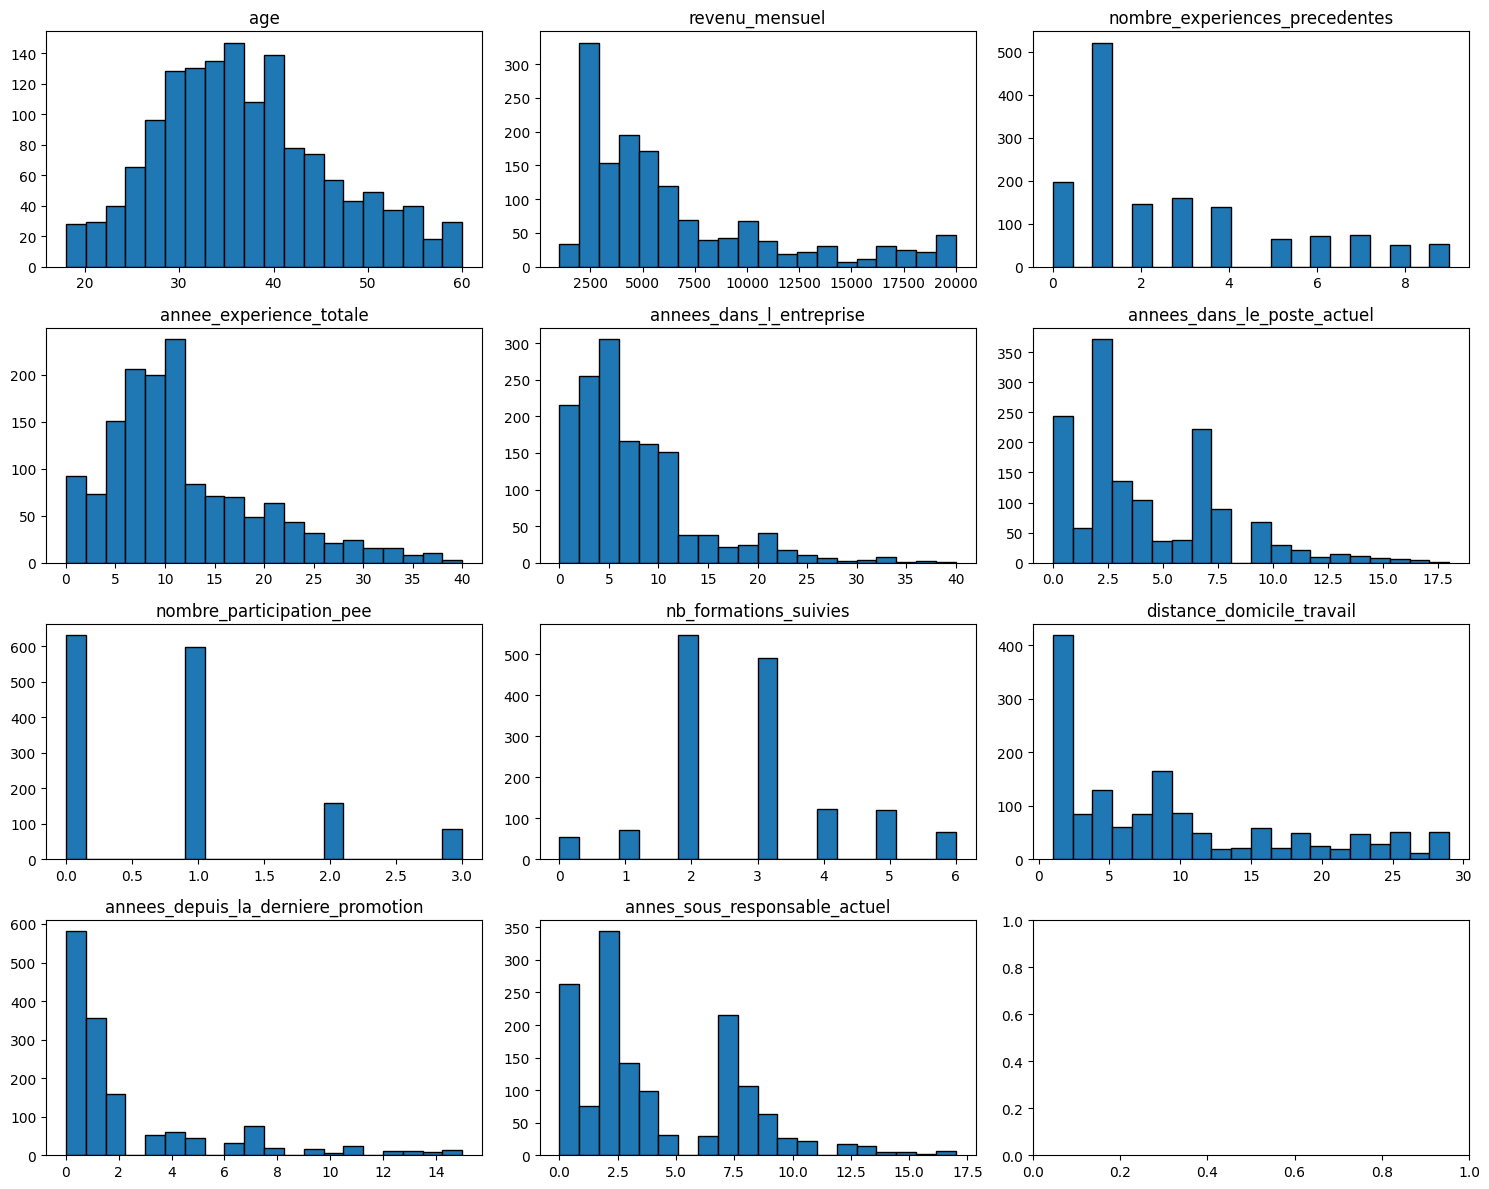

In [44]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeriques):
    axes[i].hist(df[col], bins=20, edgecolor='black')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Analyse des distributions des variables

## Observations générales

Les histogrammes montrent que plusieurs variables :

- présentent une asymétrie à droite (*right skewed*),
- sont discrètes (variables de comptage),
- contiennent potentiellement des valeurs extrêmes (*outliers*).

L’ensemble du dataset semble cohérent avec des données RH réelles :
- majorité d’employés en milieu de carrière,
- peu d’employés très seniors,
- distributions asymétriques classiques pour les revenus et l’ancienneté.

---

# Analyse variable par variable

## `id_employee`

La distribution est uniforme.

Cette variable correspond uniquement à un identifiant :
- elle n’a pas de valeur prédictive,
- elle devra être supprimée avant la modélisation.

## `age`
La distribution est en "bell-curve", plutôt centrée vers 30 et 40 qui nous donne un age moyenne pour la boîte.

## `revenu_mensuel` et `annees_dans_l_entreprise`

Les variables `revenu_mensuel` et `annees_dans_l_entreprise` semblent fortement liées : plus un employé reste longtemps dans l’entreprise, plus son revenu tend à augmenter. Cette relation suggère que l’entreprise valorise non seulement l’expérience professionnelle globale (`annee_experience_totale`), mais également l’ancienneté interne.

Cependant, très peu d’employés présentent une ancienneté supérieure à 10–15 ans. Cela peut indiquer une tendance générale à quitter l’entreprise après plusieurs années, traduisant potentiellement un niveau de turnover relativement élevé à long terme.

# Visualiser les categories

In [45]:
cat_cols = df.select_dtypes('object').columns.tolist()

C:\Users\andre\AppData\Local\Temp\ipykernel_29480\3982454930.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes('object').columns.tolist()


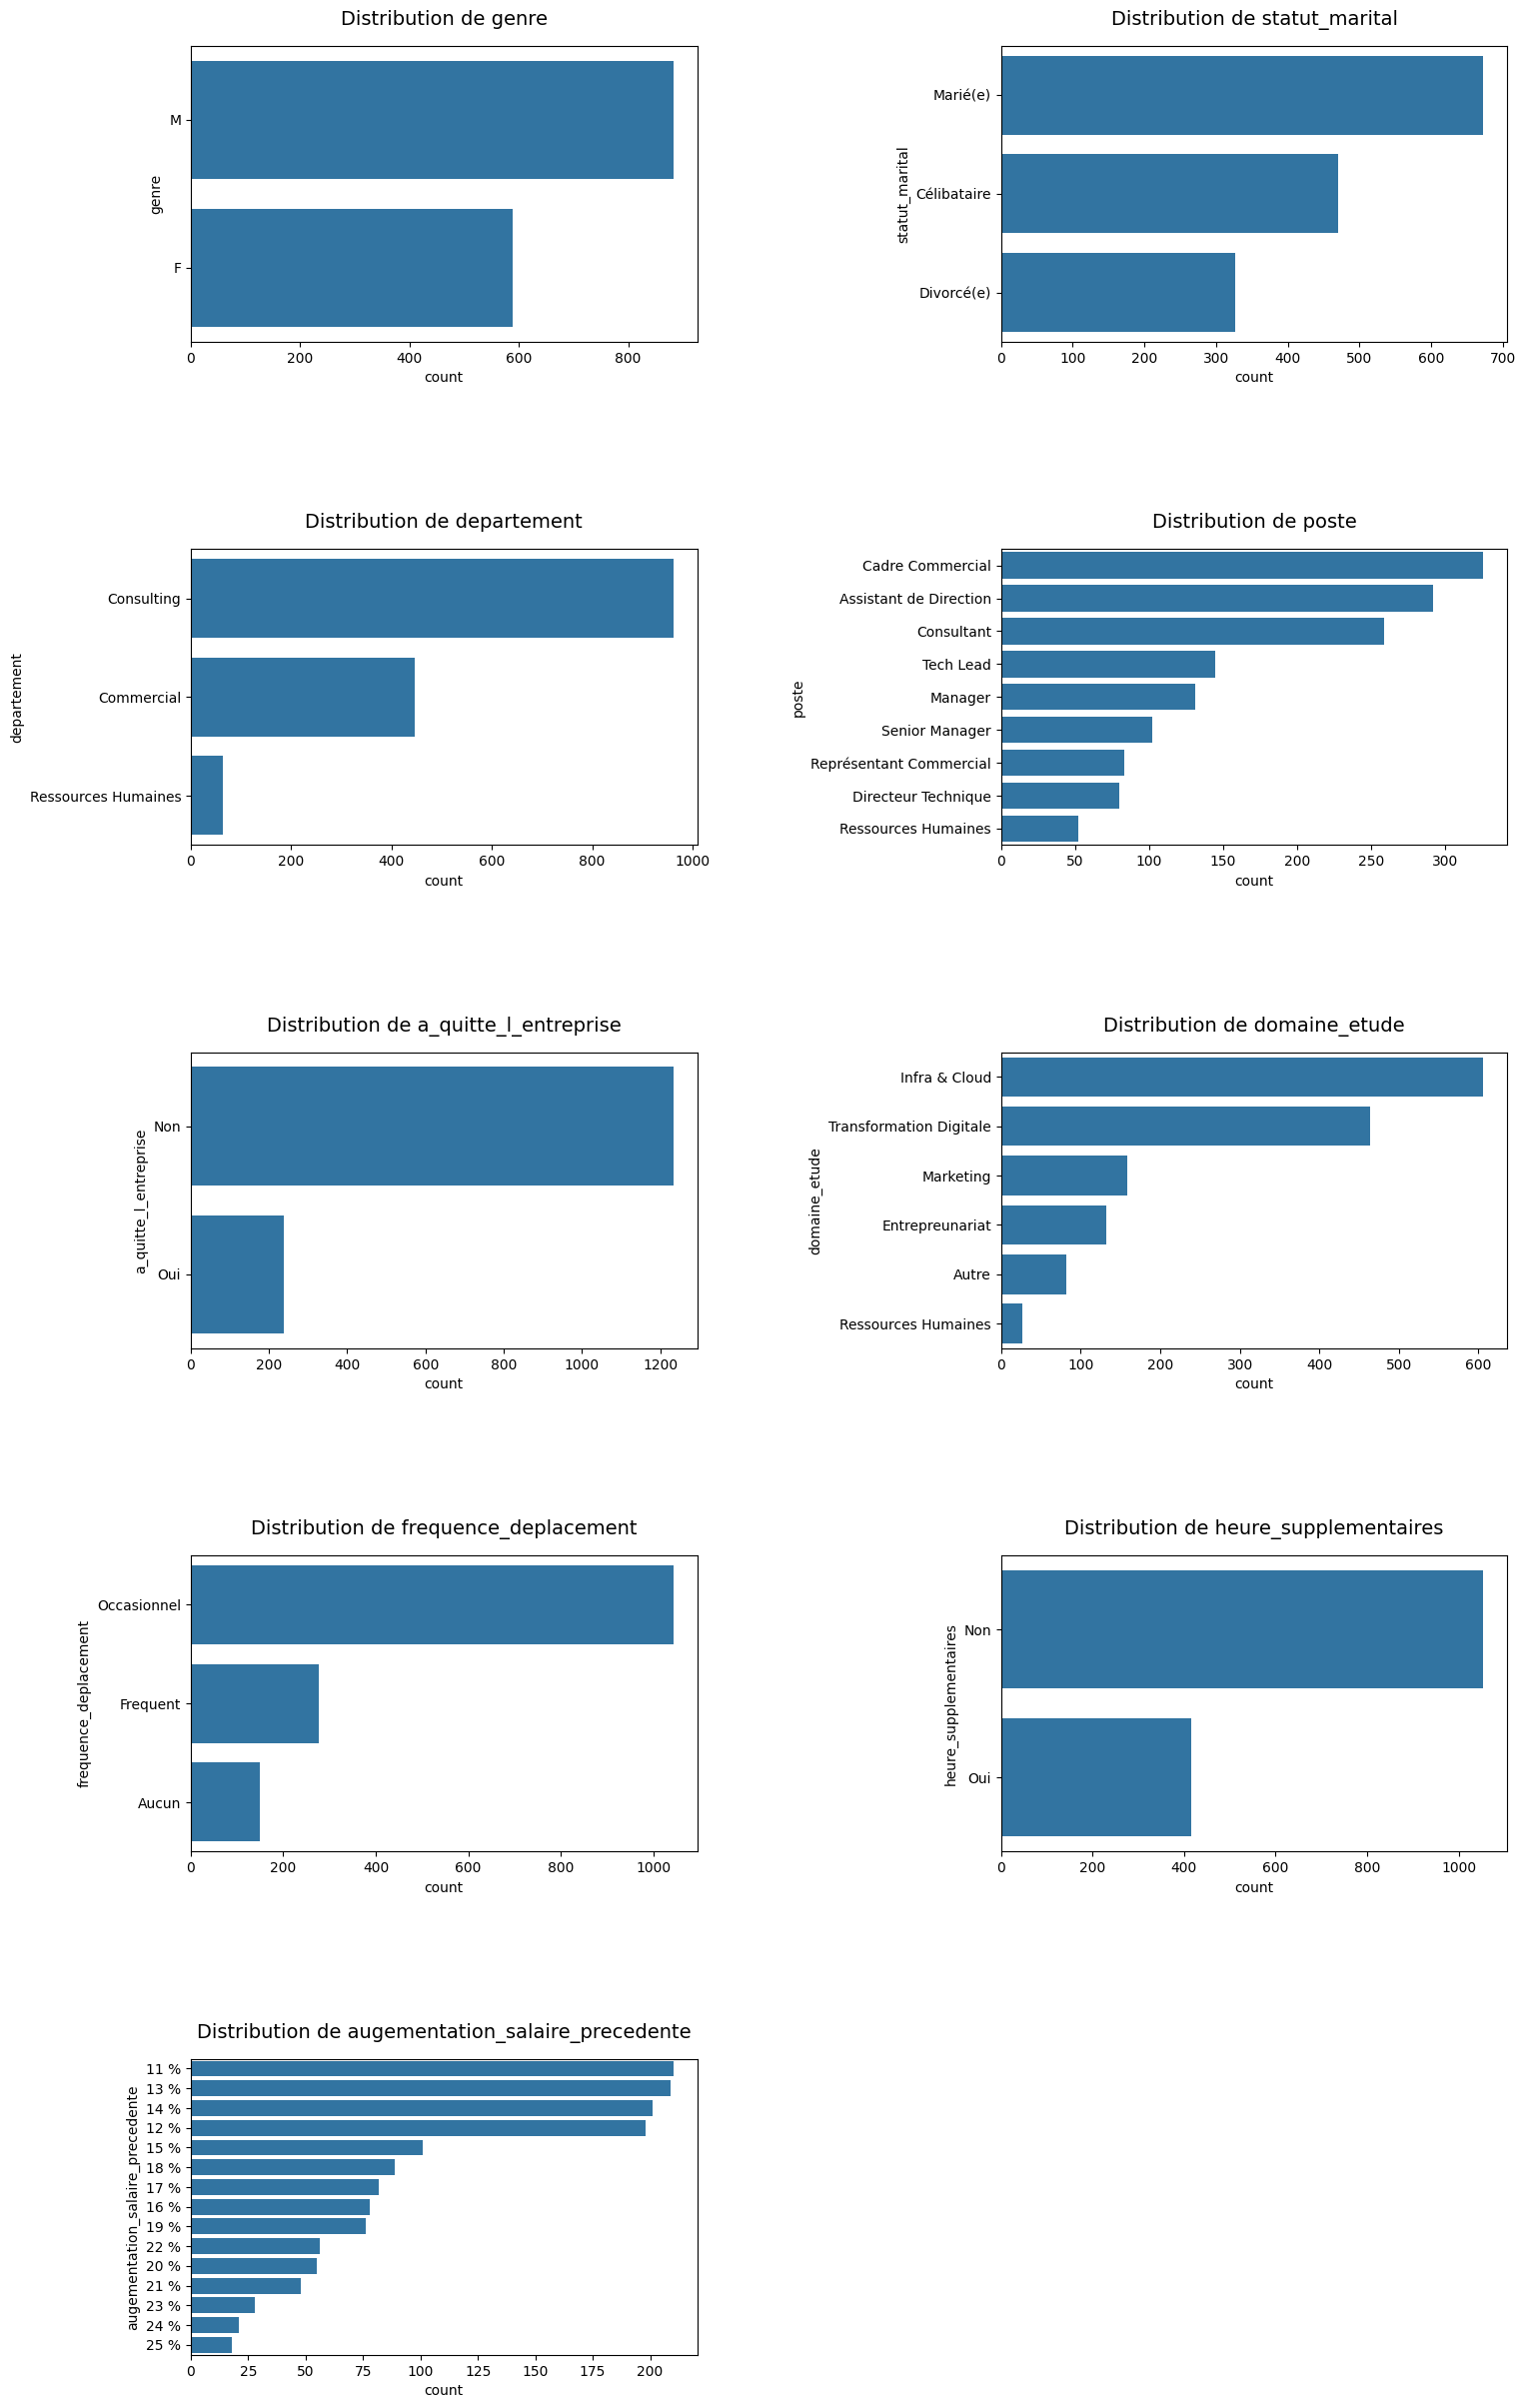

In [46]:
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(17, 6 * n_rows))

for i, col in enumerate(cat_cols, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.countplot(
        data=df,
        y=col,
        order=df[col].value_counts().index
    )

    plt.title(f"Distribution de {col}", fontsize=14, pad=15)
    # plt.xlabel("Nombre d'observations")
    plt.ylabel(col)

# Ajustement des espaces
plt.subplots_adjust(
    hspace=0.7,
    wspace=0.6
)

plt.show()

## Visualiser Cible x Numerique

En utilisant boxplot et KDE (Kernel Density Estimate - depits probability denisity at different values in a continuous variable), on voit et les outliers et la forme complete de chaque feature.

analyse bivariee

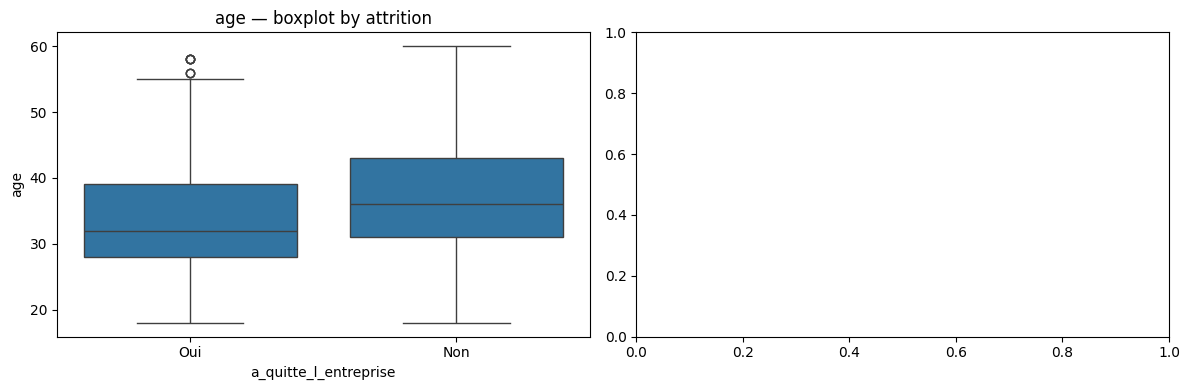

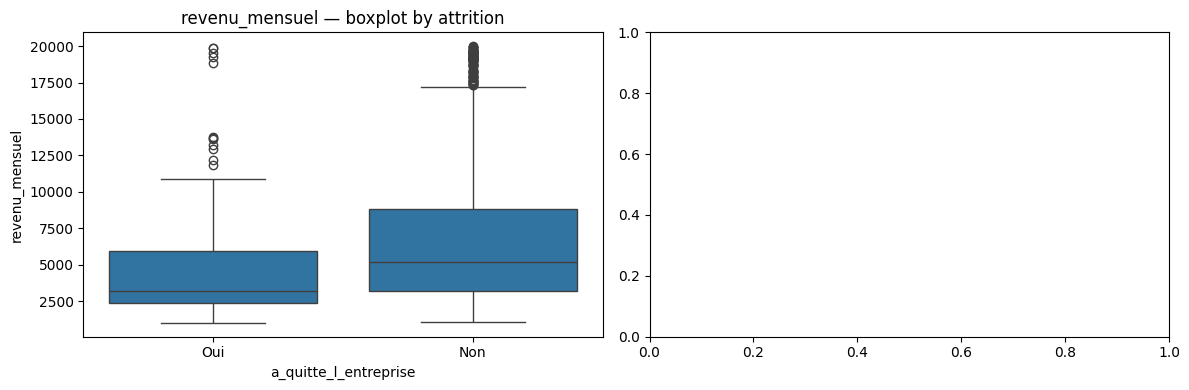

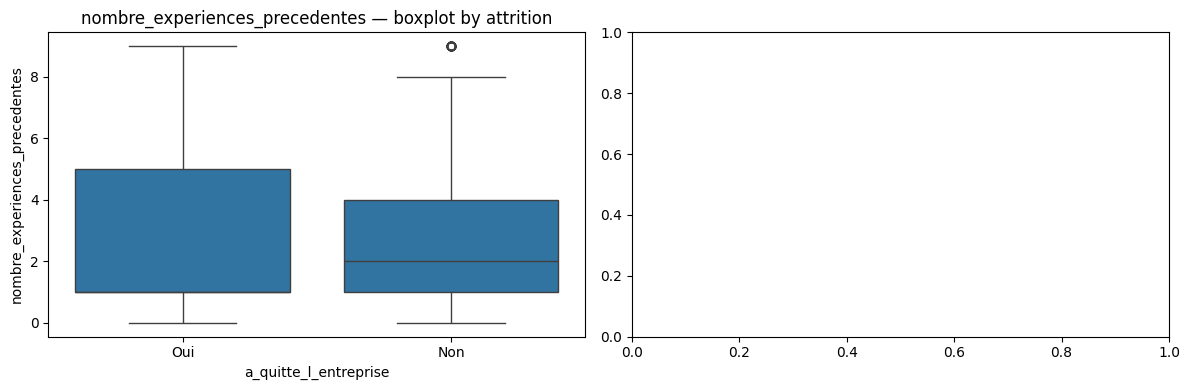

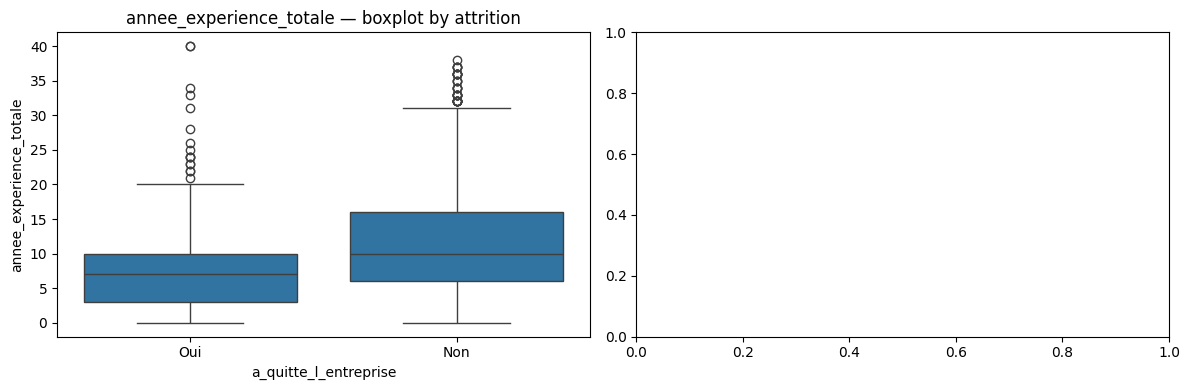

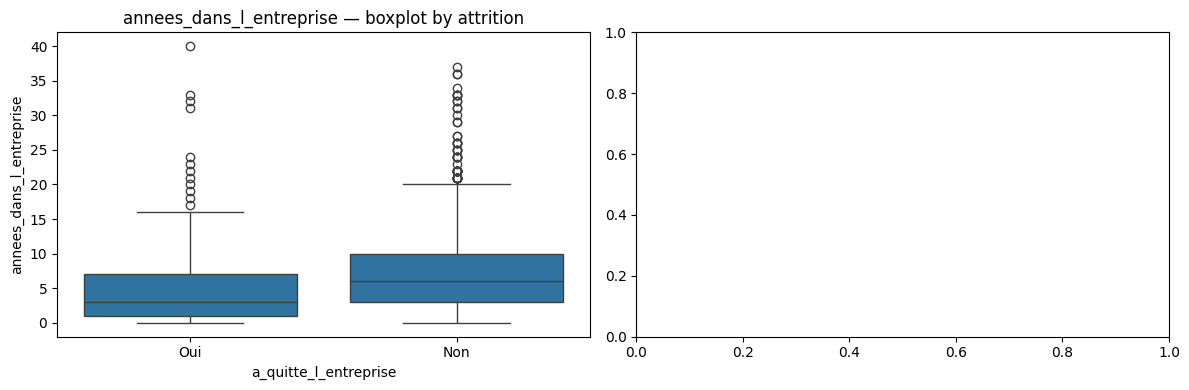

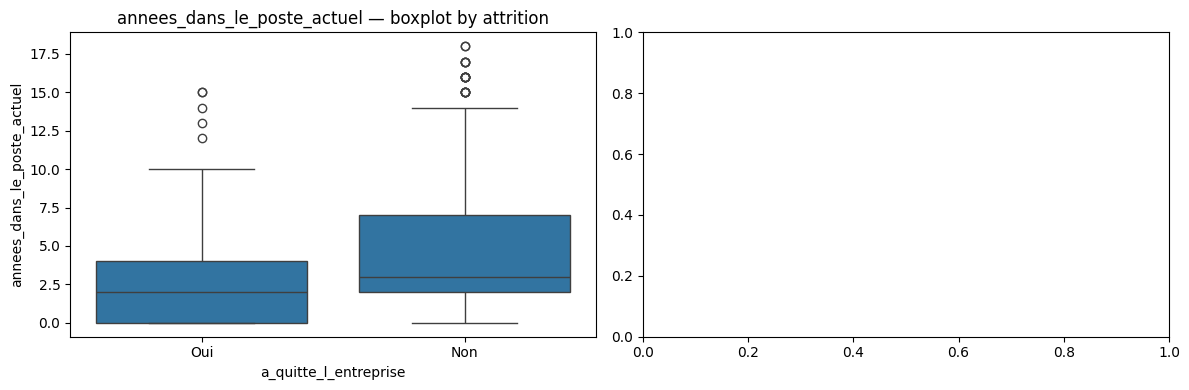

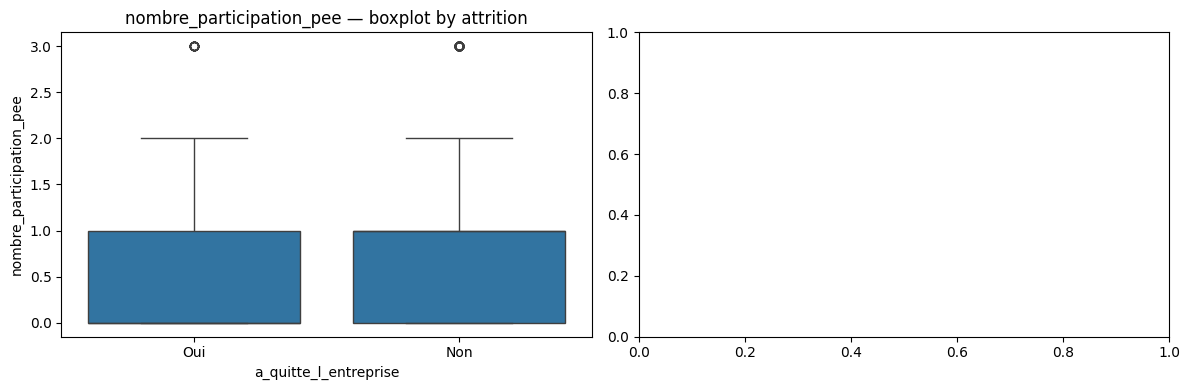

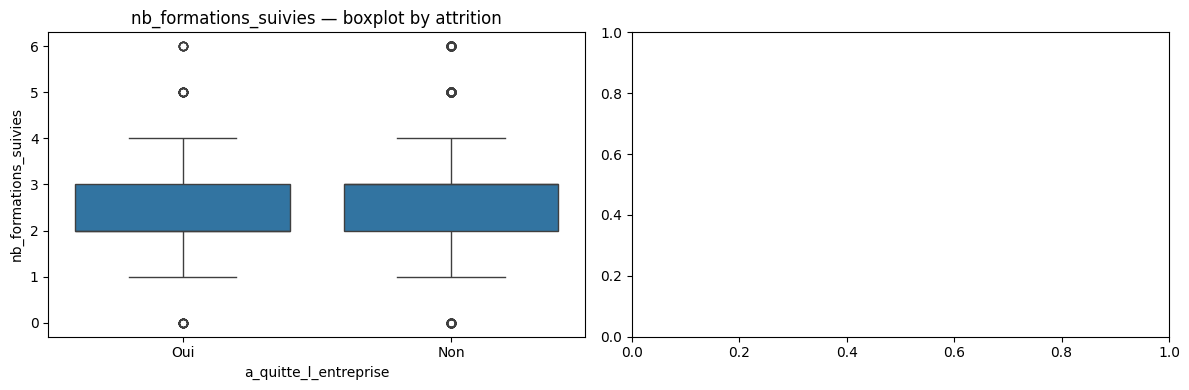

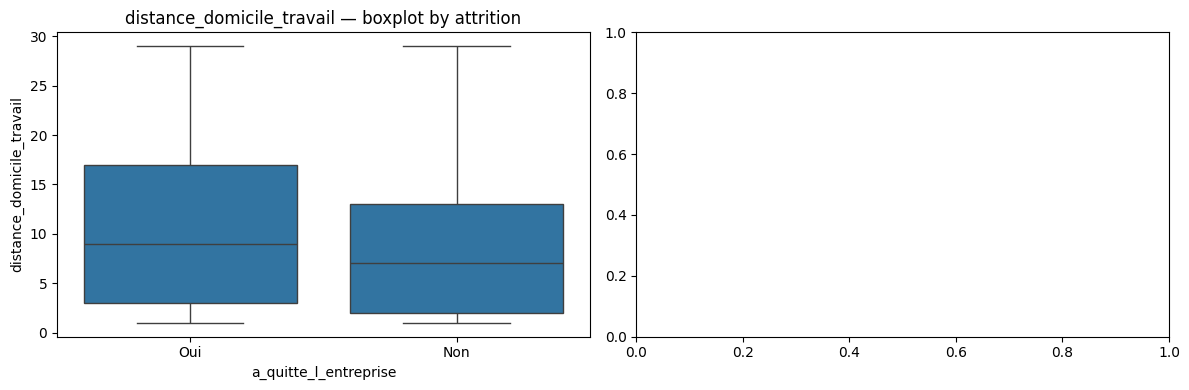

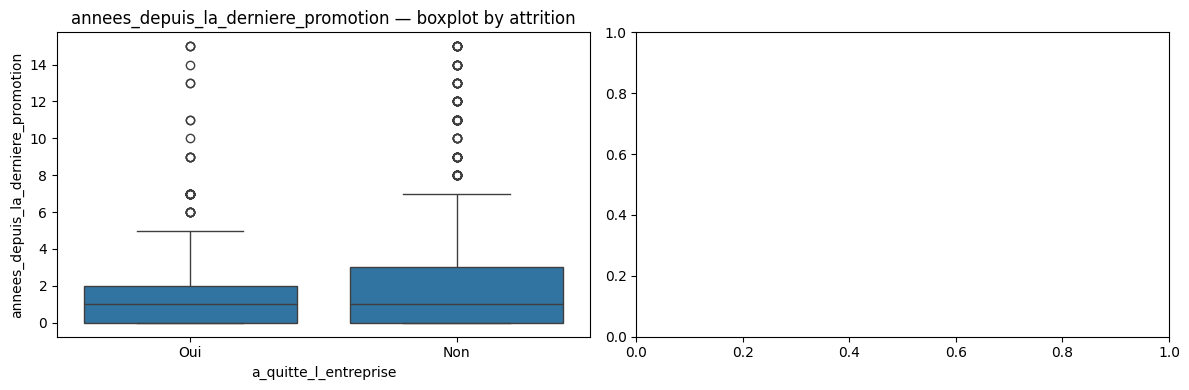

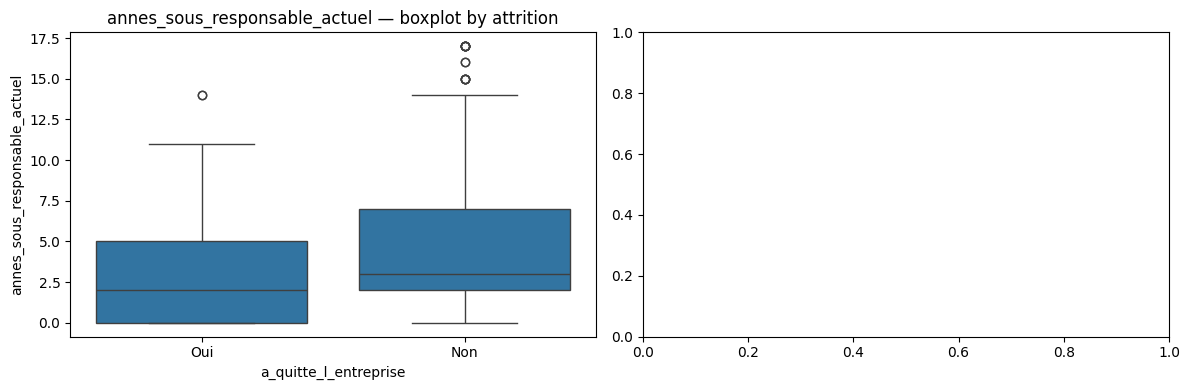

In [47]:
numerical_features = [col for col in numeriques if col != 'a_quitte_l_entreprise']

for col in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # boxplot: median + spread comparison et split by target so we get two curves on same plot - one for employees qui restent, et l'autre pour les gens qui partent
    sns.boxplot(data=df, x='a_quitte_l_entreprise', y=col, ax = axes[0])
    axes[0].set_title(f'{col} — boxplot by attrition')
    
    # KDE: full distribution shape per group
    # sns.kdeplot(data=df, x=col, hue='a_quitte_l_entreprise', fill=True, ax=axes[1])
    # axes[1].set_title(f'{col} — distribution by attrition')
    
    plt.tight_layout()
    plt.show()

* Quanti + Quanti → Scatter plot
* Quanti + Quali → Boxplot
* Quali + Quali → Bar chart

## Visualiser categories x cible

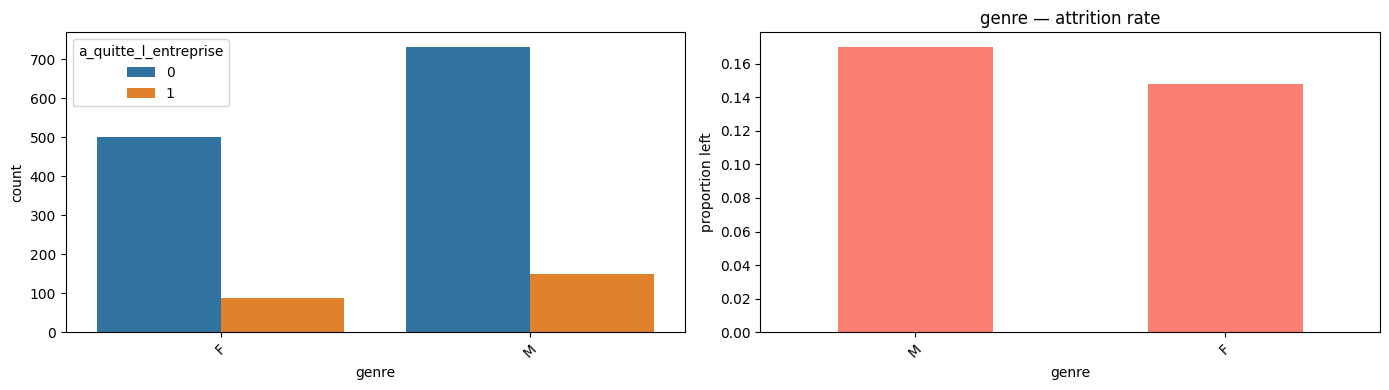

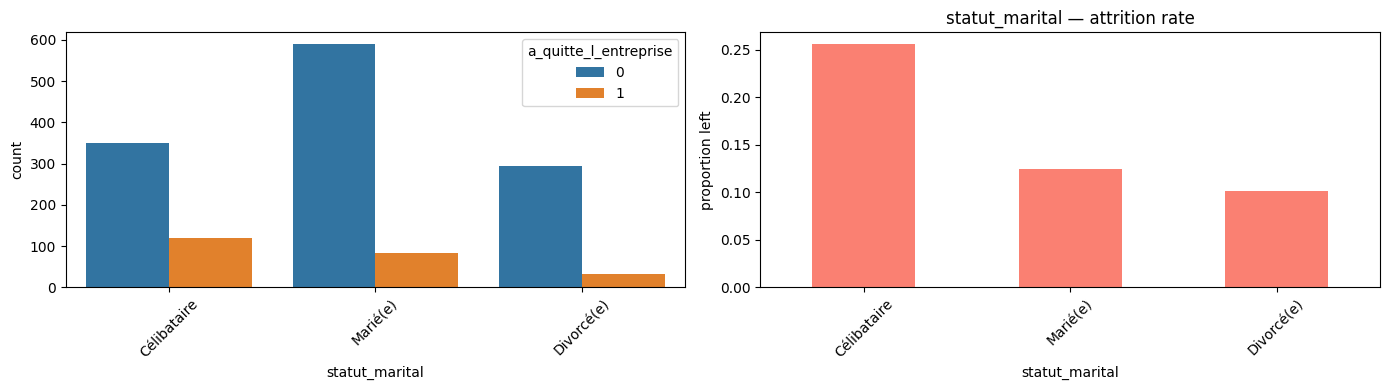

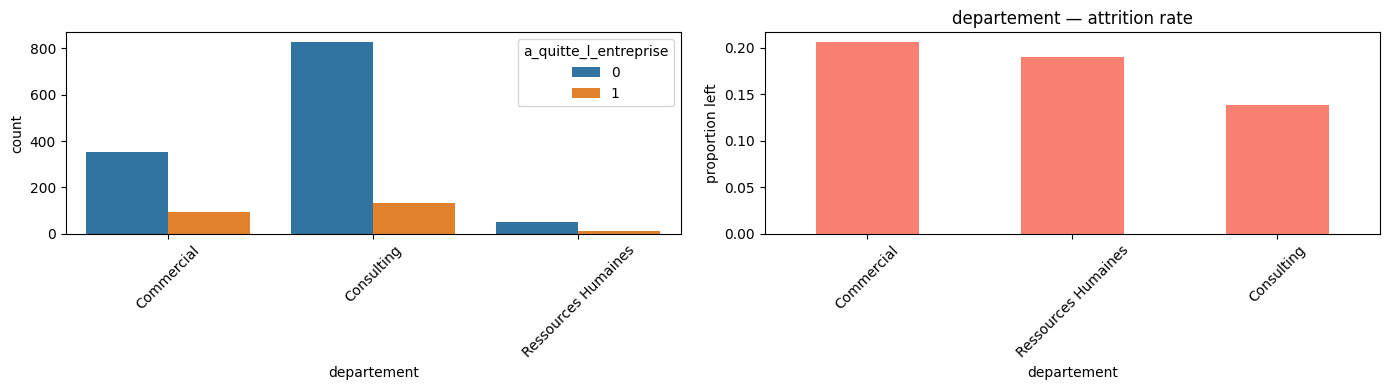

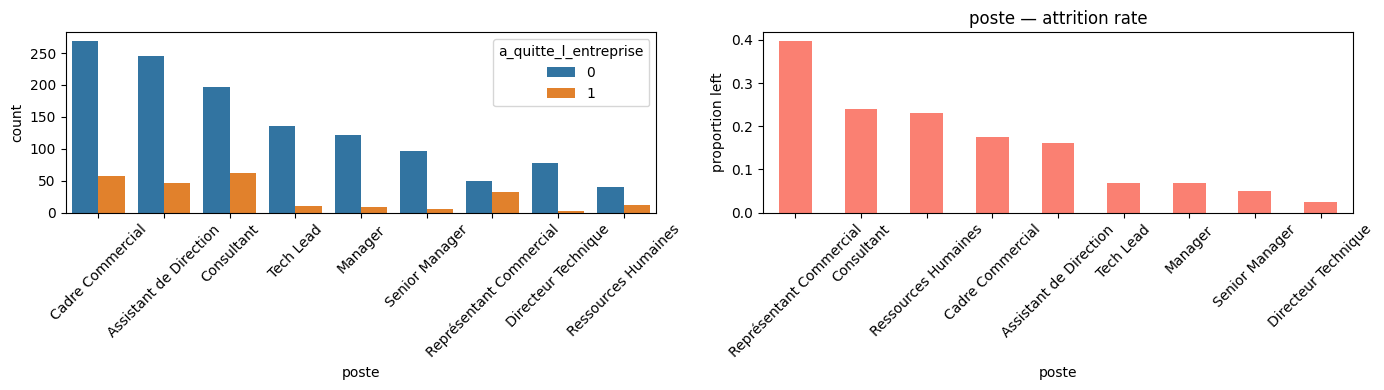

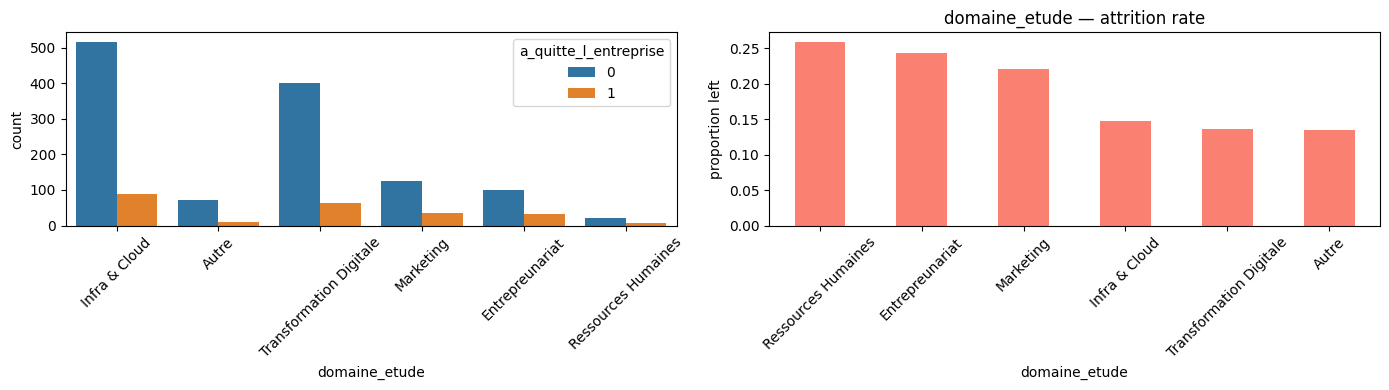

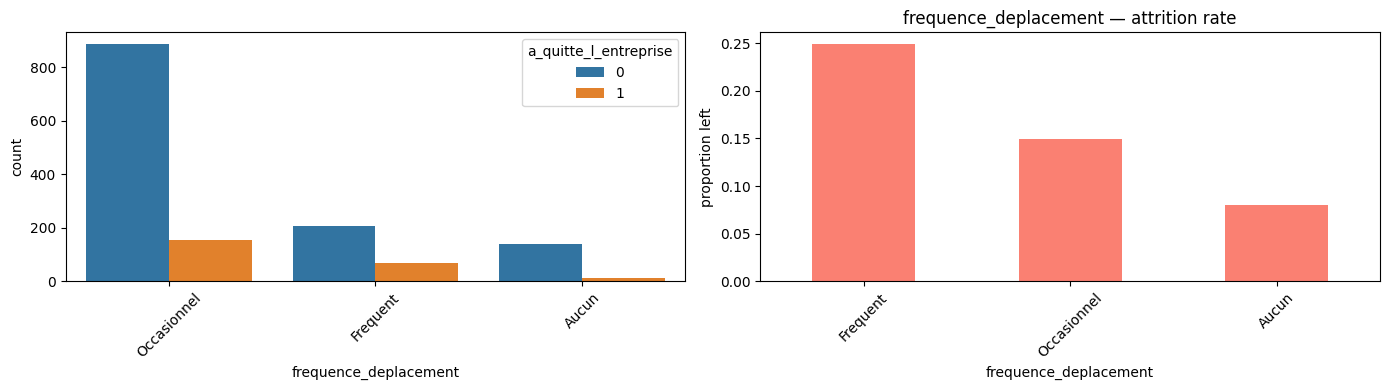

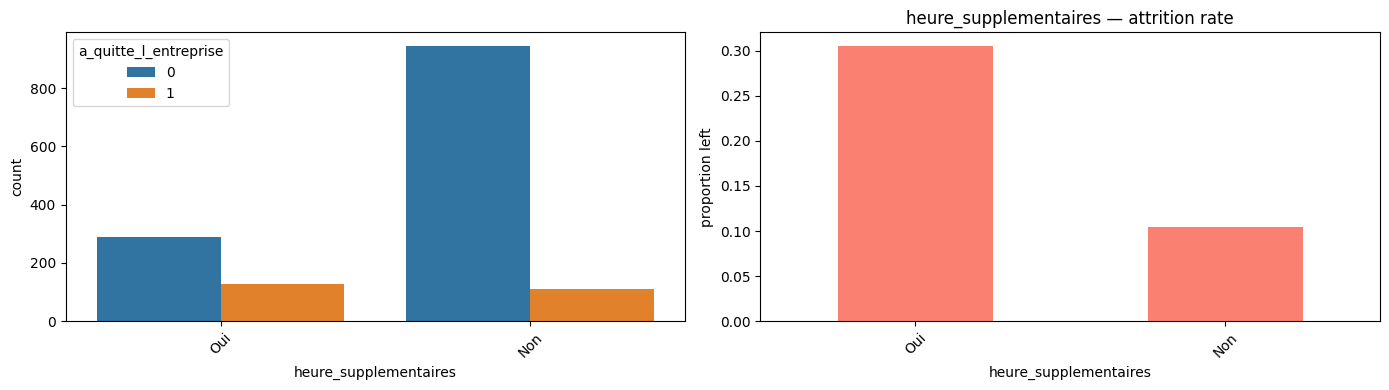

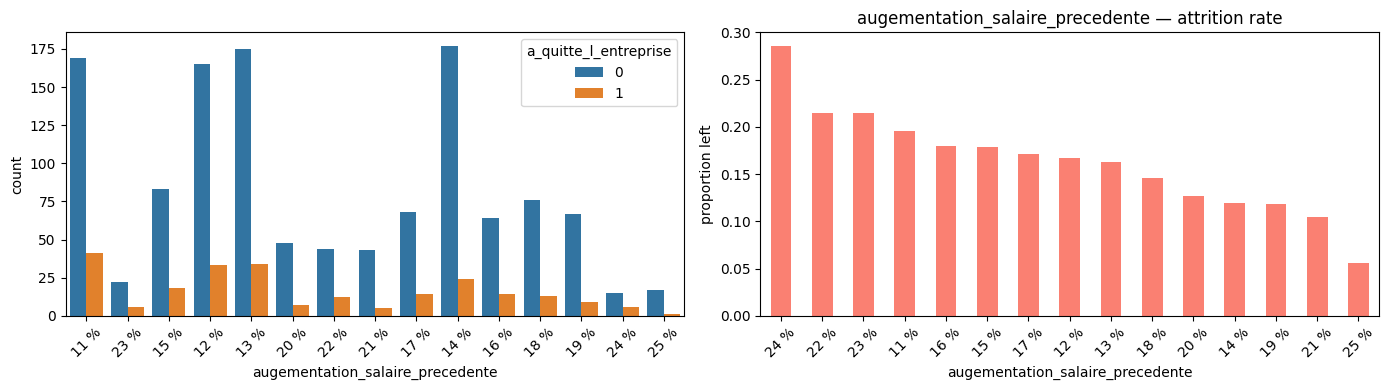

In [48]:
categorical_features = [col for col in cat_cols if col != 'a_quitte_l_entreprise']
df['a_quitte_l_entreprise'] = df['a_quitte_l_entreprise'].map({'Oui': 1, 'Non': 0})
# on change pour binaire ("oui -> 1", "non -> 0") afin de pouvoir visualiser

for col in categorical_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4)) # create figure with 1 row, two columns
    
    sns.countplot(data=df, x=col, hue='a_quitte_l_entreprise', ax =axes[0])
    axes[0].tick_params(axis='x', rotation=45)
    
    # attrition rate: proportion who left per category
    attrition_rate = df.groupby(col)['a_quitte_l_entreprise'].mean().sort_values(ascending=False)
    attrition_rate.plot(kind='bar', ax=axes[1], color='salmon')
    axes[1].set_title(f'{col} — attrition rate')
    axes[1].set_ylabel('proportion left')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## Correlation

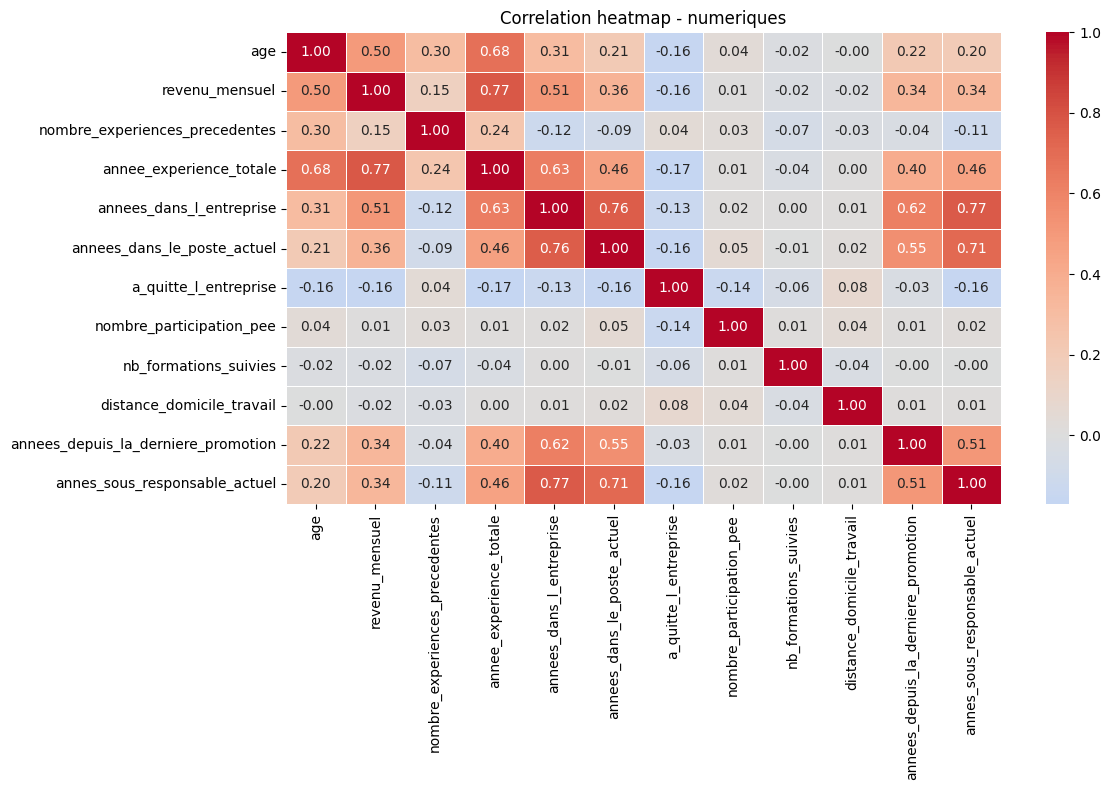

In [49]:
plt.figure(figsize=(12, 8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True, # show the numbers inside each cell
    fmt='.2f',
    cmap='coolwarm',
    center=0, 
    linewidths=0.5
)

plt.title('Correlation heatmap - numeriques')
plt.tight_layout()
plt.show()

In [50]:
df.describe()

,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,6502.931293,2.693197,11.279592,7.008163,4.229252,0.161224,0.793878,2.799320,9.192517,2.187755,4.123129
std,9.135373,4707.956783,2.498009,7.780782,6.126525,3.623137,0.367863,0.852077,1.289271,8.106864,3.222430,3.568136
min,18.000000,1009.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,2911.000000,1.000000,6.000000,3.000000,2.000000,0.000000,0.000000,2.000000,2.000000,0.000000,2.000000
50%,36.000000,4919.000000,2.000000,10.000000,5.000000,3.000000,0.000000,1.000000,3.000000,7.000000,1.000000,3.000000
75%,43.000000,8379.000000,4.000000,15.000000,9.000000,7.000000,0.000000,1.000000,3.000000,14.000000,3.000000,7.000000
max,60.000000,19999.000000,9.000000,40.000000,40.000000,18.000000,1.000000,3.000000,6.000000,29.000000,15.000000,17.000000


# Feature Engineering: 
Comprendre ce qu'on a pour transformer nos variables features.

## Ratio features

Career Loyalty Ratio : how much of their career has been here? Si bas, ils bougent beaucoup; si haut, ils sont ancres ici 

In [51]:
df['proportion_carriere_entreprise'] = (
    df['annees_dans_l_entreprise'] / (df['annee_experience_totale'] + 1)
)

Experience amene depuis outside:  
Est-ce que ces salaries sont venus au debut ou plus tard dans leur carriere ? 
-Meme si on pense pas car l'age moyenne des gens qui partents

In [52]:
df['experience_avant_entreprise'] = (
    df['annee_experience_totale'] - df['annees_dans_l_entreprise']
)

Est-ce qu'ils sont sous payees pour leurs experiences totales?

In [53]:
df['revenu_par_annee_experience'] = (
    df['revenu_mensuel'] / (df['annee_experience_totale'] + 1)
)

Est-ce que les salaires bouge du travail au travail beaucoup ? 
- s'ils ont historiquement des tenures petites, il y a une theme de depart qui n'est pas propre a la boite 

In [54]:
df['duree_moyenne_postes_precedents'] = (
    df['experience_avant_entreprise'] / (df['nombre_experiences_precedentes'] + 1)
)

### Signaux de stagnation
Ces flags sont pour signaler les salariees qui peuvent se sentir comme leur carriere a cette boite a plateau

In [55]:
df['taux_promotion'] = (
    df['annees_depuis_la_derniere_promotion'] / (df['annees_dans_l_entreprise'] + 1)
)

In [56]:
df['stagnation_poste'] = (
    df['annees_dans_le_poste_actuel'] / (df['annees_dans_l_entreprise'] + 1)
)

In [57]:
df['stagnation_poste'].value_counts()

stagnation_poste
0.000000    244
0.500000    201
0.666667    200
0.333333     78
0.875000     67
0.600000     59
0.777778     58
0.400000     56
0.636364     34
0.800000     33
0.700000     31
0.818182     31
0.727273     26
0.714286     26
0.285714     23
0.571429     19
0.750000     18
0.428571     13
0.250000      9
0.625000      8
0.272727      8
0.363636      8
0.833333      8
0.166667      8
0.181818      7
0.200000      7
0.857143      6
0.380952      6
0.583333      5
0.785714      5
0.692308      5
0.533333      5
0.222222      5
0.687500      4
0.846154      4
0.545455      4
0.125000      4
0.642857      4
0.368421      4
0.142857      4
0.444444      4
0.733333      4
0.260870      3
0.615385      3
0.812500      3
0.350000      3
0.722222      3
0.300000      3
0.318182      3
0.409091      3
0.684211      3
0.842105      3
0.437500      3
0.555556      3
0.450000      3
0.461538      2
0.866667      2
0.764706      2
0.529412      2
0.111111      2
0.588235      2
0.73913

### Commute

In [58]:
df['distance_domicile_travail'].describe()

count    1470.000000
mean        9.192517
std         8.106864
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max        29.000000
Name: distance_domicile_travail, dtype: float64

Binning distance for travel between work and domicile

In [59]:
df['zone_distance'] = pd.cut(
    df['distance_domicile_travail'],
    bins=[0, 5, 15, 30],
    labels=['proche', 'moyen', 'loin']
)

In [60]:
print(df['zone_distance'].value_counts(dropna=False))

zone_distance
proche    632
moyen     509
loin      329
Name: count, dtype: int64


In [61]:
df['jamais_promu'] = (df['annees_depuis_la_derniere_promotion'] == 0).astype(int)
df['aucune_formation'] = (df['nb_formations_suivies'] == 0).astype(int)
df['aucune_participation_pee'] = (df['nombre_participation_pee'] == 0).astype(int)

# La nouvelle correlation

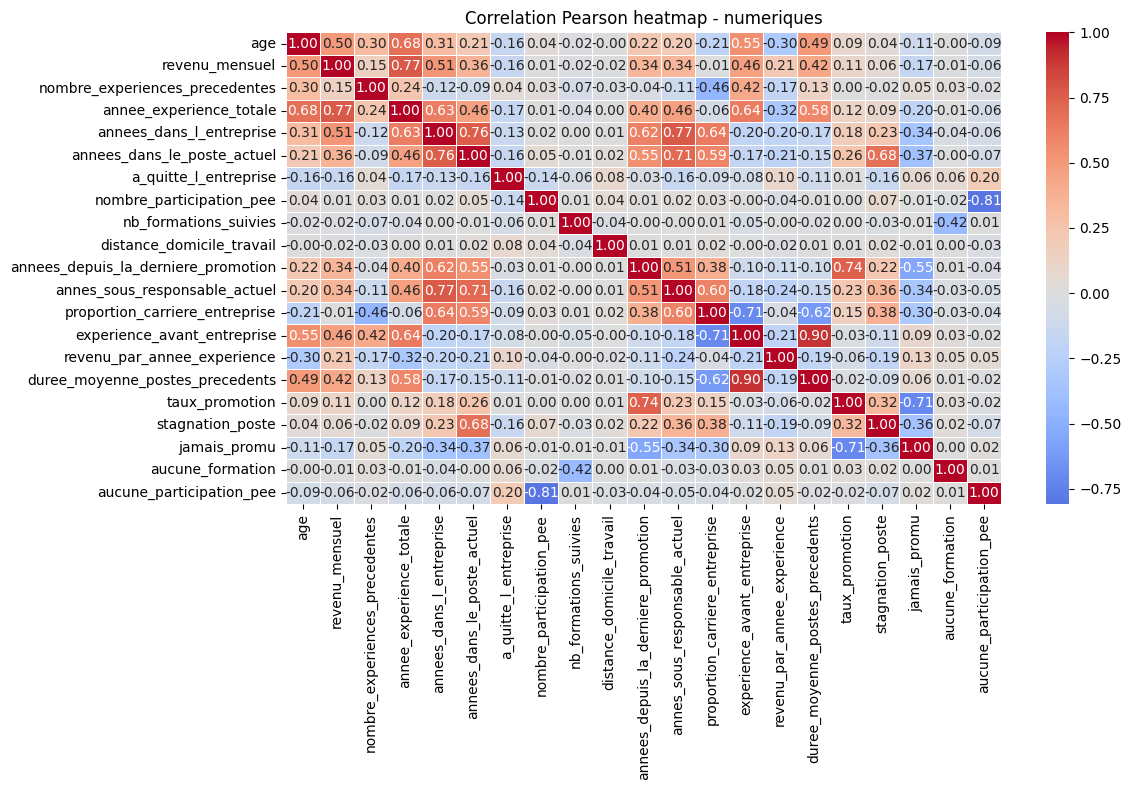

In [62]:
plt.figure(figsize=(12, 8))

corr_matrix = df.corr(numeric_only=True, method='pearson')

sns.heatmap(
    corr_matrix,
    annot=True, # show the numbers inside each cell
    fmt='.2f',
    cmap='coolwarm',
    center=0, 
    linewidths=0.5
)

plt.title('Correlation Pearson heatmap - numeriques')
plt.tight_layout()
plt.show()

# Préparer les données pour le modèle

Séparer X et y

In [63]:
X = df.drop(columns=['a_quitte_l_entreprise'])
y = df['a_quitte_l_entreprise']

Encoder les variables catégorielles restantes

In [64]:
X = pd.get_dummies(X, drop_first=True)

## La Stratification: 
Le probleme du coeur : nos donnees ne sont pas du tout "balanced" - c'est a dire - en ayant des classes et une reparition presque egale.

En effet, notre class 'B' - attrition - prendre 16%, qui fait qu'elle est une classe rare.

Si jamais, nous allons faire un modele base sur l'accuracy avec une base de donnees aussi mal repartitionee, nous risquons d'avoir une evaluation non pas fiable. 

On rectifie ce probleme avec (stratify=y); cela nous preserver la meme ratio exacte pour chaque split qu'on fera.

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Nous pouvons verifier si la stratification a fonctionnee

In [66]:
print("Train :", y_train.value_counts(normalize=True))
print("Test  :", y_test.value_counts(normalize=True))

Train : a_quitte_l_entreprise
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Test  : a_quitte_l_entreprise
0    0.840136
1    0.159864
Name: proportion, dtype: float64


Maintenant faut scaler les features numeriques

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit UNIQUEMENT sur train et non pas sur

Rappel : nous avons besoin de scaler, surtout pour certains modeles - notamment la Regression Logistique (notre premier modele). 

Each feature has different scales of measures, and if there is a greater value in one variable than the rest, it will dominate the calculcation.

Scaling brings everything onto the same playing field : scaled_value = (value - mean) / standard_deviation

Every feature ends up with mean = 0 and standard deviation = 1. Now the model can compare features fairly.

Et aussi : nous fit seulement X_test afin de faire en sorte que scaler.transform (X_Test) va etre appliquer sans reapplication (eviter data leakage)


# Modele 0 : Dummy


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(dummy.score(X_test, y_test))
print(classification_report(y_test, y_pred)) # regarde ici pour Dummy 

0.8401360544217688
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       247
           1       0.48      0.49      0.48        47

    accuracy                           0.83       294
   macro avg       0.69      0.69      0.69       294
weighted avg       0.83      0.83      0.83       294



Ayant une balance des classes qui sont pas du tout equilibre, `most_frequent`
nous scorera une precision de ~0.84. Cela nous demontre pourquoi la precision tout seul n'est pas adequate. 

# Modele 1 : Logisitic Regression

Cela nous donne une baseline lineaire pour la classification.

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=42)
clf.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

ajouter la matrice de confusion pour chaque modele - interprete, faux pos, faux neg, vrai pos, vrai pos
--> ensuite tu utilise la precision, recall, f1-score

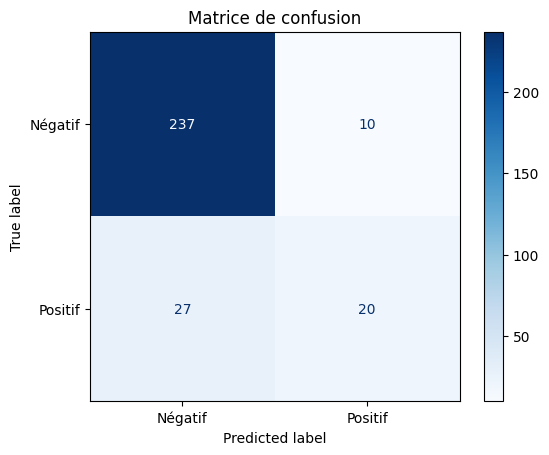

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       247
           1       0.67      0.43      0.52        47

    accuracy                           0.87       294
   macro avg       0.78      0.69      0.72       294
weighted avg       0.86      0.87      0.86       294

AUROC : 0.8376259798432251


In [75]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test_scaled) #applies a default 0.5 threshold
y_proba = clf.predict_proba(X_test_scaled)[:, 1] # gives the underlying
# probability, letting us move th e threhold; here, model assigns 
# each row a probability of being class 1

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Négatif', 'Positif'])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()
print(classification_report(y_test, y_pred))
print("AUROC :", roc_auc_score(y_test, y_proba))

La regression logistique est un modele de classificaiton. On donne nos features (nos X colonnes), et pour chaque ligne, notre modele produit une probabilitie entre 0 et 1 - "how likely is this row to be class 1?"

---
Our model draws a boundary line (a hyperplane) through data that tries to separate the two classes. 
It works well when:
- les deux classes sont un peu pres separable lineairement - on peut dessiner une borne assez droit entre les deux
- si on veut interpretability - chaque feature a une coeff qui nous dit a quel point c'est fait partie de classe 1 ou classe 0.
- on a une nombre reasonable des features, not too noisy

//

Precision - model calls class 1 , it's 67% correct; the other 33% is off.
Recall - Class 1 recall = 0.43 -> of the 47 truly-class-1 rows, model only found 43% of them 
F1- a single number blending precision and recall (their harmonic mean). Class 1 F1 = 0.52 -> mediocre, because recall is dragging it down - useful when you want one number to summarize how well a class is handled 
// demande a fernanda

In [71]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

# For SVC , comme pour LogRef, on utilise X_train_scaled
models = {"Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVC": SVC(class_weight='balanced', probability=True, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print("AUROC :", roc_auc_score(y_test, y_proba))


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.36      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.61      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294

AUROC : 0.7730209320354897

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.50      0.19      0.28        47

    accuracy                           0.84       294
   macro avg       0.68      0.58      0.59       294
weighted avg       0.80      0.84      0.81       294

AUROC : 0.7917994659316048

=== SVC ===
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       247
           1       0.48      0.49      0.48        47

    accuracy                           0.83       294
   macro av

RAndom Forest = construit une centaine des arbes des decisions - each on random slice of data and features 

la semaine pro:

look at models 
regarder confusion matrix
essayer des les performances pour les modeles
--> comparer les modeles 
--> optimiser les modeles
why not AUROC courbe quand on a classes desquilibres?
when we have classes desquilibres, what are the metrics we should be using for model perofrmance?
how to fix class desequilibres how can we fix this !!!?